# 03 — TM1990 blocking over five ERA5 winters

**Question.** How often does the TM1990 index detect atmospheric blocking
over the Euro-Atlantic sector, and does a five-winter pilot reproduce the
expected longitude structure?

**Key results.**

- With persistence evaluated per longitude (±10° tolerance), the detection funnel is monotonic on one denominator: candidate 4.8–12.2%, sector 3.1–10.5%, persistent 1.4–7.8% of days per longitude per winter.
- 2022–23 is the blockiest winter (6.5% persistent days per longitude) and 2021–22 the calmest (1.4%).
- On the widened ±90°E domain the widest blocked sector reaches ~93° (2020–21) and ~92° (2024–25); the old ±40°E domain would have truncated these.
- The five-winter DJF blocked-day frequency vs longitude peaks over the Atlantic–European sector, qualitatively matching the shape of published TM climatologies (see text) but not their amplitude — five winters are too few.

## Method

Tibaldi & Molteni (1990): at each longitude, a block needs a reversed
meridional gradient. With bands centred near 60°N shifted by −4°/0/+4°:

$$GHGS = \frac{Z(\phi_0) - Z(\phi_0 - 20°)}{20°} > 0, \qquad GHGN = \frac{Z(\phi_0 + 20°) - Z(\phi_0)}{20°} < -10\ \mathrm{m\,deg^{-1}}$$

Three filters, all on **daily-mean** Z500 (TM1990 is a daily index; using
daily means also makes "5 days" literal):

1. **candidate**: GHGS > 0 and GHGN < −10 m deg⁻¹ at a longitude;
2. **sector**: candidates must form a contiguous ≥ 20° longitude sector;
3. **persistent**: a longitude stays inside an unbroken ≥ 5-day run during
   which some longitude within **±10°** is blocked — the tolerance lets a
   slow-drifting block count as one event, and all three fractions share one
   denominator (% of day–longitude cells), so the funnel is monotonic.

Domain: 30–85°N, **90°W–90°E** — wide enough that Atlantic and European
sectors are never truncated (whole-globe ARCO chunks make the wider crop
free).

In [1]:
# Purpose: project root, config, shared plotting style.
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from eurogrid import plotting

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))
plotting.apply_style()

In [2]:
# Purpose: load the five winters of Z500 on the wide blocking domain.
from datetime import datetime

import xarray as xr

from eurogrid.data.era5 import load_era5_z500

dom = cfg["blocking"]["domain"]
z500 = {}
for w in cfg["blocking"]["benchmark_windows"]:
    z500[w["label"]] = load_era5_z500(
        datetime.fromisoformat(w["start"]),
        datetime.fromisoformat(w["end"]),
        lat_min=dom["lat_min"],
        lat_max=dom["lat_max"],
        lon_min=dom["lon_min"],
        lon_max=dom["lon_max"],
        cache_dir=cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
print({k: dict(v.sizes) for k, v in z500.items()})

{'2020-21': {'time_z500': 360, 'lat': 221, 'lon': 721}, '2021-22': {'time_z500': 360, 'lat': 221, 'lon': 721}, '2022-23': {'time_z500': 360, 'lat': 221, 'lon': 721}, '2023-24': {'time_z500': 364, 'lat': 221, 'lon': 721}, '2024-25': {'time_z500': 360, 'lat': 221, 'lon': 721}}


In [3]:
# Purpose: daily mean, TM1990 detection, per-longitude persistence per winter.
from eurogrid.diagnostics.blocking import (
    blocked_day_frequency,
    daily_mean_z500,
    detect_tm1990,
    persistence_summary,
)

bcfg = cfg["blocking"]
det = {}
for label, z in z500.items():
    daily = daily_mean_z500(z)
    r = detect_tm1990(
        daily,
        phi0_deg=bcfg["phi0_deg"],
        arm_deg=bcfg["arm_deg"],
        scan_offsets_deg=tuple(bcfg["scan_offsets_deg"]),
        ghgn_threshold_m_per_deg=bcfg["ghgn_threshold_m_per_deg"],
        min_sector_width_deg=bcfg["min_sector_width_deg"],
    )
    s = persistence_summary(
        r["blocking"],
        timestep_hours=24,
        min_persistence_days=bcfg["min_persistence_days"],
        tolerance_deg=bcfg["persistence_lon_tolerance_deg"],
    )
    det[label] = {"daily": daily, "result": r, "summary": s}

In [4]:
# Purpose: per-winter funnel — all three filters share one denominator.
rows = []
for label, d in det.items():
    r, s = d["result"], d["summary"]
    rows.append(
        {
            "winter": label,
            "candidate_%": float(r["candidate"].mean()) * 100,
            "sector_%": float(r["blocking"].mean()) * 100,
            "persistent_%": float(s["persistent_blocking"].mean()) * 100,
            "widest_span_deg": float((r["blocking"].sum("lon") * 0.25).max()),
        }
    )
funnel = pl.DataFrame(rows).with_columns(
    pl.col("candidate_%", "sector_%", "persistent_%", "widest_span_deg").round(2)
)
display(funnel)

winter,candidate_%,sector_%,persistent_%,widest_span_deg
str,f64,f64,f64,f64
"""2020-21""",7.26,4.08,1.93,93.25
"""2021-22""",6.07,4.11,1.41,69.25
"""2022-23""",12.15,10.46,6.46,89.25
"""2023-24""",4.8,3.14,1.69,62.0
"""2024-25""",11.27,9.82,7.8,92.25


**Reading the funnel.** Each row gives the share of day–longitude cells
passing each filter. Because persistence is now evaluated *per longitude*
(within ±10°), `persistent ≤ sector ≤ candidate` holds — the earlier
denominator mismatch (persistence measured on a domain-wide run) is gone.

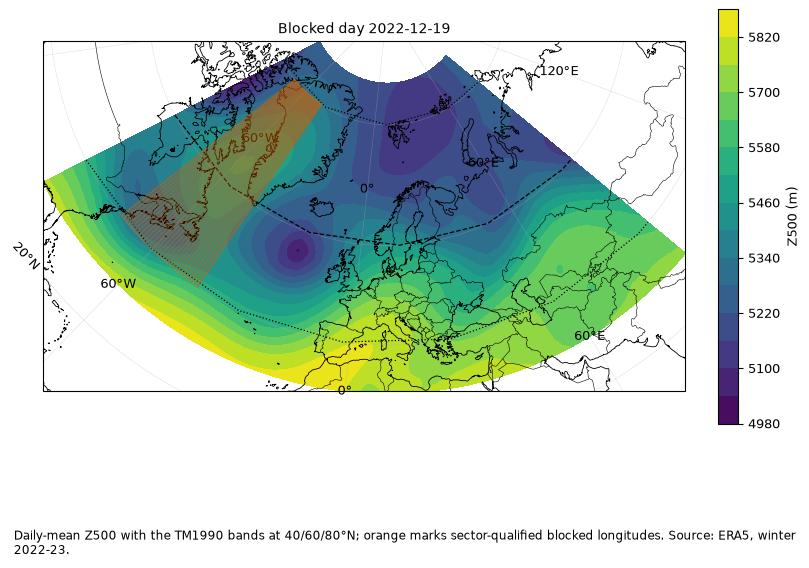

In [5]:
# Purpose: worked example — one persistent-blocked day: Z500 map + TM bands + sector.
import cartopy.crs as ccrs

label = "2022-23"
r = det[label]["result"]
daily = det[label]["daily"]
s = det[label]["summary"]
persist_days = s["persistent_blocking"].any("lon")
persist_idx = np.flatnonzero(persist_days.values)
day_i = int(persist_idx[persist_idx.size // 2])
day = daily.isel(time_z500=day_i)

fig, ax = plotting.map_axes(extent=(-90, 90, 30, 85))
pc = ax.contourf(
    day["lon"], day["lat"], day, levels=14, cmap=plotting.SEQUENTIAL_CMAP, transform=ccrs.PlateCarree()
)
fig.colorbar(pc, ax=ax, shrink=0.7, label="Z500 (m)")
for phi, style in [(40, ":"), (60, "--"), (80, ":")]:
    ax.plot([-90, 90], [phi, phi], color="k", ls=style, lw=0.9, transform=ccrs.PlateCarree())
blocked_lons = r["blocking"].isel(time_z500=day_i)
blon = blocked_lons["lon"].values[blocked_lons.values]
for lo in blon[::4]:
    ax.plot([lo, lo], [40, 80], color=plotting.PALETTE[3], alpha=0.5, transform=ccrs.PlateCarree())
ax.set_title(f"Blocked day {str(day['time_z500'].values)[:10]}")
plotting.caption(
    fig,
    "Daily-mean Z500 with the TM1990 bands at 40/60/80°N; orange marks sector-qualified "
    "blocked longitudes. Source: ERA5, winter " + label + ".",
)
plt.show()

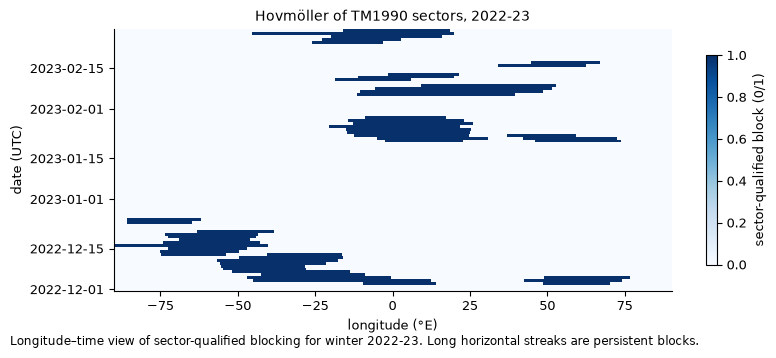

In [6]:
# Purpose: Hovmoller of the sector mask for the same winter.
fig, ax = plt.subplots(figsize=(9, 3.4))
mask = r["blocking"].astype(int)
pcm = ax.pcolormesh(mask["lon"], mask["time_z500"], mask, cmap="Blues", shading="auto")
ax.set_xlabel("longitude (°E)")
ax.set_ylabel("date (UTC)")
fig.colorbar(pcm, ax=ax, label="sector-qualified block (0/1)", shrink=0.8)
ax.set_title(f"Hovmöller of TM1990 sectors, {label}")
plotting.caption(
    fig,
    "Longitude–time view of sector-qualified blocking for winter "
    + label
    + ". Long horizontal streaks are persistent blocks.",
)
plt.show()

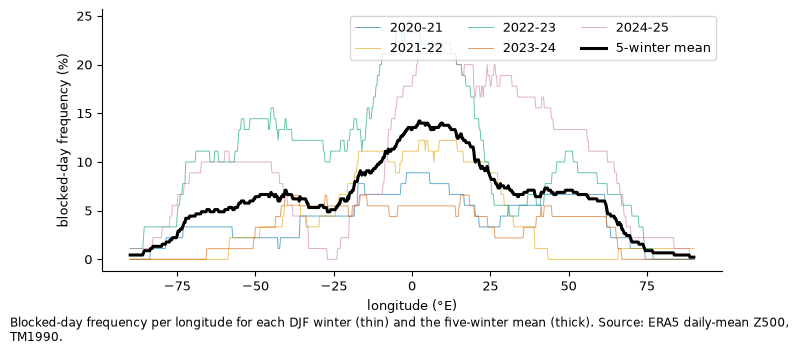

In [7]:
# Purpose: blocked-day frequency vs longitude — five winters thin, mean thick.
fig, ax = plt.subplots(figsize=(8, 3.4))
for label, d in det.items():
    f = blocked_day_frequency(d["result"]["blocking"])
    ax.plot(f["lon"], f, lw=0.7, alpha=0.6, label=label)
mean_f = xr.concat([blocked_day_frequency(d["result"]["blocking"]) for d in det.values()], dim="winter").mean(
    "winter"
)
ax.plot(mean_f["lon"], mean_f, lw=2.2, color="k", label="5-winter mean")
ax.set_xlabel("longitude (°E)")
ax.set_ylabel("blocked-day frequency (%)")
ax.legend(ncol=3)
plotting.caption(
    fig,
    "Blocked-day frequency per longitude for each DJF winter (thin) and the "
    "five-winter mean (thick). Source: ERA5 daily-mean Z500, TM1990.",
)
plt.show()

## Against a published climatology

TM-type indices on multi-decadal reanalyses (e.g. Davini et al. 2012,
*J. Climate*; Scherrer et al. 2006, *JGR*) find a broad DJF maximum over
the Atlantic sector west of ~0°E and a secondary European maximum around
0–40°E, with frequencies of several percent per longitude. Our five-winter
mean should reproduce the *shape* (two broad sectors, not a single spike);
individual winters will deviate strongly — five years cannot reproduce a
climatology. Where the mean sits relative to those published curves is a
qualitative check only; we do not quote their numbers here.

## Limitations and next step

- Five winters is a pilot, not a climatology; the thin curves show how large
  year-to-year spread is.
- TM1990 is a longitude-scan index — it misses blocks that do not reverse
  the 60°N gradient (e.g. some Scandinavian highs).
- The ±10° persistence tolerance is a documented choice, not a calibrated
  one.
- **Next:** notebook 04 asks whether detected blocks coincide with renewable
  droughts — association only, no causality claim.